# Практическая работа 
Выполняла: Екатерина Т. (@kkkkatag)

#### Условие (Неделя 0):

Для выполнения задания предоставлен реестр всех предпринимателей из ФНС.

**Требуется** его подготовить к работе (интересуют юридические лица, среднее и малые предприятия, в видах деятельности указывайте 41.20 Строительство жилых и нежилых зданий).

**Определить** насколько перспективна отрасль строительства с помощью подсчёта EBITA всех компаний по годам. Для этого требуется получить все нужные финансовые данные компаний с сайта бухгалтерской отчётности ФНС. 

**Построить графики** (x=процент роста чистой прибыли компании относительно N-летней давности, y=Количество компаний с таким процентом) x-целое число, N выбирается самостоятельно. Также требуется **написать вывод** после увиденных графиков.

Выбрать **500 крупнейших компаний по выручке** и нанести их на карту в соответствии с местом регистрации.


### Загрузка данных реестра

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Примечание:** Исходный реестр содержит очень большое количество записей, поэтому для сокращения времени предварительная обработка данных была выполнена вручную в Excel. В итоговом файле содеражтся только соответствующие условиям записи.

In [7]:
df = pd.read_excel("Реестр2.xlsx", header=2)
df.head()

,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,20,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Юридическое лицо,Малое предприятие,1025004907080,5038038838,41.20 Строительство жилых и нежилых зданий,50 - Московская область,Пушкино г,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,36.0
1,52,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Юридическое лицо,Среднее предприятие,1025007270551,5027006369,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Дзержинский,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,201.0
2,4653,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Юридическое лицо,Малое предприятие,1021400692048,1414006922,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,35.0
3,4668,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Юридическое лицо,Малое предприятие,1043301806415,3327332190,41.20 Строительство жилых и нежилых зданий,33 - Владимирская область,NaN,г Владимир,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,52.0
4,4674,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Юридическое лицо,Малое предприятие,1027807999988,7816061297,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,21.0


Размерность: 

In [8]:
df.shape

(8927, 23)

### Парсинг данных 

In [9]:
import requests
import time
session = requests.Session()
session.headers.update({
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/152.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://bo.nalog.gov.ru/"
})

Вспомогательные функции 

In [13]:
def get_org_id(inn):
    response = session.get(
        "https://bo.nalog.gov.ru/advanced-search/organizations/search",
        params={"query": inn, "page": 0},
        timeout=30,
        allow_redirects=False
    )

    response.raise_for_status()

    data = response.json()

    if len(data["content"]) == 0:
        return None

    return data["content"][0]["id"]


def get_bfo(org_id):
    response = session.get(
        f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo",
        timeout=30
    )

    response.raise_for_status()

    return response.json()

Функция, которая достаёт financialResult:

In [15]:
def get_financial_result(report):
    corrections = report.get("corrections", [])

    if corrections:
        correction = corrections[0]
        return correction.get("financialResult", {})

    type_corrections = report.get("typeCorrections", [])

    if type_corrections:
        correction = type_corrections[0].get("correction", {})
        return correction.get("financialResult", {})

    return {}

Основной цикл, собирающий данные 

In [ ]:
financial_data = []
errors = []

for i, inn_value in enumerate(df["ИНН"], start=1):

    try:
        inn = str(int(inn_value))

        org_id = get_org_id(inn)

        if org_id is None:
            errors.append((inn, "Организация не найдена"))
            continue
        bfo = get_bfo(org_id)
        for report in bfo:
            fin = get_financial_result(report)
            financial_data.append({
                "ИНН": inn,
                "org_id": org_id,
                "Год": report.get("period"),
                "Выручка_2110": fin.get("current2110"),
                "Себестоимость_2120": fin.get("current2120"),
                "Валовая_прибыль_2100": fin.get("current2100"),
                "Коммерческие_расходы_2210": fin.get("current2210"),
                "Управленческие_расходы_2220": fin.get("current2220"),
                "Прибыль_от_продаж_2200": fin.get("current2200"),
                "Проценты_к_уплате_2330": fin.get("current2330"),
                "Прибыль_до_налога_2300": fin.get("current2300"),
                "Налог_на_прибыль_2410": fin.get("current2410"),
                "Чистая_прибыль_2400": fin.get("current2400")
            })
        time.sleep(0.3)
    except Exception as e:
        errors.append((inn_value, str(e)))
    if i % 100 == 0:
        print(f"Обработано {i} из {len(df)}")
        pd.DataFrame(financial_data).to_csv(
            "financial_data_checkpoint.csv",
            index=False)

In [ ]:
finance = pd.DataFrame(financial_data)
finance.head()

### Анализ полученных данных

In [ ]:
finance = pd.DataFrame(financial_data)

finance.to_csv(
    "financial_data_full.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame(
    errors,
    columns=["ИНН", "Ошибка"]
).to_csv(
    "parsing_errors.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Данные сохранены")
print("Строк с финансовыми данными:", len(finance))
print("Ошибок:", len(errors))

In [21]:
finance = pd.read_csv(
    "financial_data_full.csv",
    dtype={"ИНН": str}
)

finance.head()

,ИНН,org_id,Год,Выручка_2110,Себестоимость_2120,Валовая_прибыль_2100,Коммерческие_расходы_2210,Управленческие_расходы_2220,Прибыль_от_продаж_2200,Проценты_к_уплате_2330,Прибыль_до_налога_2300,Налог_на_прибыль_2410,Чистая_прибыль_2400
0,5038038838,5872486,2023,108966.0,90500.0,18466.0,1151.0,25408.0,-8093.0,3334.0,-20665.0,-248.0,-20913.0
1,5038038838,5872486,2021,184044.0,150023.0,34021.0,2692.0,37142.0,-5813.0,5601.0,3430.0,-320.0,3080.0
2,5038038838,5872486,2024,112540.0,95619.0,16921.0,0.0,25710.0,-8789.0,1521.0,-19938.0,-191.0,-20129.0
3,5038038838,5872486,2022,118633.0,83747.0,34886.0,4126.0,28364.0,2396.0,141.0,20219.0,-336.0,19518.0
4,5038038838,5872486,2025,140064.0,103274.0,36790.0,NaN,36435.0,355.0,11869.0,-457.0,-63.0,-520.0


In [23]:
print(finance.shape)
print(finance["ИНН"].nunique())
print(finance["Год"].value_counts().sort_index())

(40336, 13)
8842
Год
2021    8405
2022    8715
2023    8241
2024    7725
2025    7250
Name: count, dtype: int64


In [25]:
finance.describe()

,org_id,Год,Выручка_2110,Себестоимость_2120,Валовая_прибыль_2100,Коммерческие_расходы_2210,Управленческие_расходы_2220,Прибыль_от_продаж_2200,Проценты_к_уплате_2330,Прибыль_до_налога_2300,Налог_на_прибыль_2410,Чистая_прибыль_2400
count,4.033600e+04,40336.000000,3.897100e+04,3.899400e+04,2.370200e+04,4.173000e+03,1.983300e+04,2.394300e+04,1.739800e+04,2.405300e+04,3.689700e+04,3.982100e+04
mean,7.202013e+06,2022.918187,3.137965e+05,2.668217e+05,5.849917e+04,1.583600e+04,3.637740e+04,2.461141e+04,7.427292e+03,2.028024e+04,-2.738152e+03,1.113547e+04
std,3.422133e+06,1.397638,6.935303e+05,6.355844e+05,1.588847e+05,5.831021e+04,1.126063e+05,1.495000e+05,7.257060e+04,1.638079e+05,2.683054e+04,1.166880e+05
min,2.474000e+03,2021.000000,-7.986100e+04,-7.339332e+07,-9.643230e+05,-1.424850e+05,-3.887380e+05,-1.143526e+07,-1.512150e+05,-1.147125e+07,-1.490562e+06,-1.147125e+07
25%,4.334646e+06,2022.000000,4.532100e+04,3.365325e+04,3.756250e+03,0.000000e+00,5.147000e+03,0.000000e+00,1.000000e+00,2.530000e+02,-1.761000e+03,6.100000e+01
50%,8.322686e+06,2023.000000,1.445040e+05,1.187560e+05,2.002650e+04,5.310000e+02,1.604200e+04,4.142000e+03,4.300000e+02,3.560000e+03,-1.600000e+02,1.919000e+03
75%,9.986823e+06,2024.000000,3.451270e+05,2.990422e+05,6.082225e+04,9.142000e+03,3.983900e+04,2.091250e+04,2.790000e+03,1.652800e+04,3.020000e+02,9.959000e+03
max,1.229916e+07,2025.000000,7.713800e+07,1.751350e+07,7.044290e+06,1.326627e+06,1.198151e+07,7.038450e+06,4.673051e+06,7.182788e+06,1.793000e+06,5.740162e+06


Проверяем количество пропусков 

In [27]:
finance.isna().sum().sort_values(ascending=False)

Коммерческие_расходы_2210      36163
Проценты_к_уплате_2330         22938
Управленческие_расходы_2220    20503
Валовая_прибыль_2100           16634
Прибыль_от_продаж_2200         16393
Прибыль_до_налога_2300         16283
Налог_на_прибыль_2410           3439
Выручка_2110                    1365
Себестоимость_2120              1342
Чистая_прибыль_2400              515
ИНН                                0
org_id                             0
Год                                0
dtype: int64

In [29]:
indirect_cols = [
    "Чистая_прибыль_2400",
    "Проценты_к_уплате_2330",
    "Налог_на_прибыль_2410"
]

coverage_indirect = pd.DataFrame({
    "Есть значений": finance[indirect_cols].notna().sum(),
    "Пропусков": finance[indirect_cols].isna().sum(),
    "Доля заполненных, %": finance[indirect_cols].notna().mean() * 100
})

coverage_indirect.round(2)

,Есть значений,Пропусков,"Доля заполненных, %"
Чистая_прибыль_2400,39821,515,98.72
Проценты_к_уплате_2330,17398,22938,43.13
Налог_на_прибыль_2410,36897,3439,91.47


In [31]:
finance[indirect_cols].notna().all(axis=1).sum()

16564

### Расчет EBITA

По определению, EBITA = EBIT + амортизация нематериальных активов. В используемых данных БФО показатель амортизации НМА не представлен отдельной строкой в структурированном отчёте о финансовых результатах. Поэтому непосредственно рассчитать EBITA по имеющимся данным невозможно.

В дальнейших расчётах в качестве приближения EBITA используется EBIT. Такое приближение эквивалентно предположению, что амортизация нематериальных активов относительно невелика.

Было принято решение проводить анализ только по строками с полным набором необходимых данных и это покрывает только **41%** данных (16 564 наблюдений).

In [55]:
required_cols = [
    "Чистая_прибыль_2400",
    "Проценты_к_уплате_2330",
    "Налог_на_прибыль_2410"
]

ebita_data = finance.dropna(subset=required_cols).copy()

# EBIT используется как приближение EBITA
ebita_data["EBITA_proxy"] = (
    ebita_data["Чистая_прибыль_2400"]
    + ebita_data["Проценты_к_уплате_2330"]
    + ebita_data["Налог_на_прибыль_2410"]
)

print("Количество наблюдений:", len(ebita_data))
print(
    "Доля от всей выборки:",
    round(len(ebita_data) / len(finance) * 100, 1),
    "%"
)

Количество наблюдений: 16564
Доля от всей выборки: 41.1 %


In [57]:
ebita_by_year = (
    ebita_data
    .groupby("Год")["EBITA_proxy"]
    .agg(["count", "sum", "mean", "median"])
)

ebita_by_year

,count,sum,mean,median
Год,,,,
2021,3143,27658585.0,8800.058861,3852.0
2022,3251,48664793.0,14969.176561,4131.0
2023,3231,60348425.0,18677.940266,5000.0
2024,3120,78299740.0,25096.070513,6113.5
2025,3819,71320993.0,18675.305839,3080.0


### EBITA по всем компаниям 

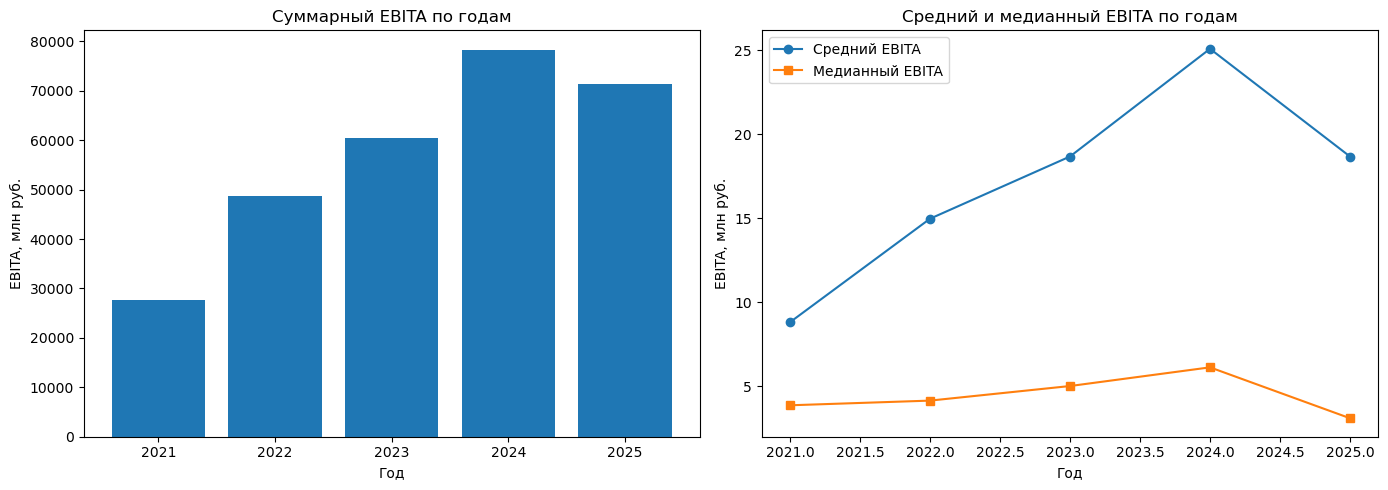

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Суммарный показатель отрасли
axes[0].bar(
    ebita_by_year.index.astype(str),
    ebita_by_year["sum"] / 1000
)

axes[0].set_title("Суммарный EBITA по годам")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("EBITA, млн руб.")


# Среднее и медиана
axes[1].plot(
    ebita_by_year.index,
    ebita_by_year["mean"] / 1000,
    marker="o",
    label="Средний EBITA"
)

axes[1].plot(
    ebita_by_year.index,
    ebita_by_year["median"] / 1000,
    marker="s",
    label="Медианный EBITA"
)

axes[1].set_title("Средний и медианный EBITA по годам")
axes[1].set_xlabel("Год")
axes[1].set_ylabel("EBITA, млн руб.")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Вывод
В 2021–2024 гг. EBITA строительных компаний устойчиво рос, что свидетельствует о положительной динамике отрасли. В 2025 г. наблюдается снижение показателей, хотя число наблюдений выросло. Это может указывать на ухудшение результатов у типичной компании, но вывод стоит проверить на одинаковом наборе компаний по годам.

### EBITA на одинаковом наборе компаний по годам (сбалансированноне сравнение)

In [65]:
years = [2021, 2022, 2023, 2024, 2025]

# Считаем, за сколько лет есть данные у каждой компании
common_inns = (
    ebita_data[ebita_data["Год"].isin(years)]
    .groupby("ИНН")["Год"]
    .nunique()
)

# Оставляем только компании с данными за все 5 лет
common_inns = common_inns[
    common_inns == len(years)
].index

print("Компаний с данными за все годы:", len(common_inns))

Компаний с данными за все годы: 1647


In [67]:
balanced = ebita_data[
    ebita_data["ИНН"].isin(common_inns)
    & ebita_data["Год"].isin(years)
].copy()

In [79]:
balanced_by_year = (
    balanced
    .groupby("Год")["EBITA_proxy"]
    .agg(["count", "sum", "mean", "median"])
)
balanced_by_year

,count,sum,mean,median
Год,,,,
2021,1647,12799334.0,7771.301761,5159.0
2022,1647,30370422.0,18439.843352,6372.0
2023,1647,40349987.0,24499.081360,7192.0
2024,1647,40614269.0,24659.544019,7869.0
2025,1647,32594250.0,19790.072860,4560.0


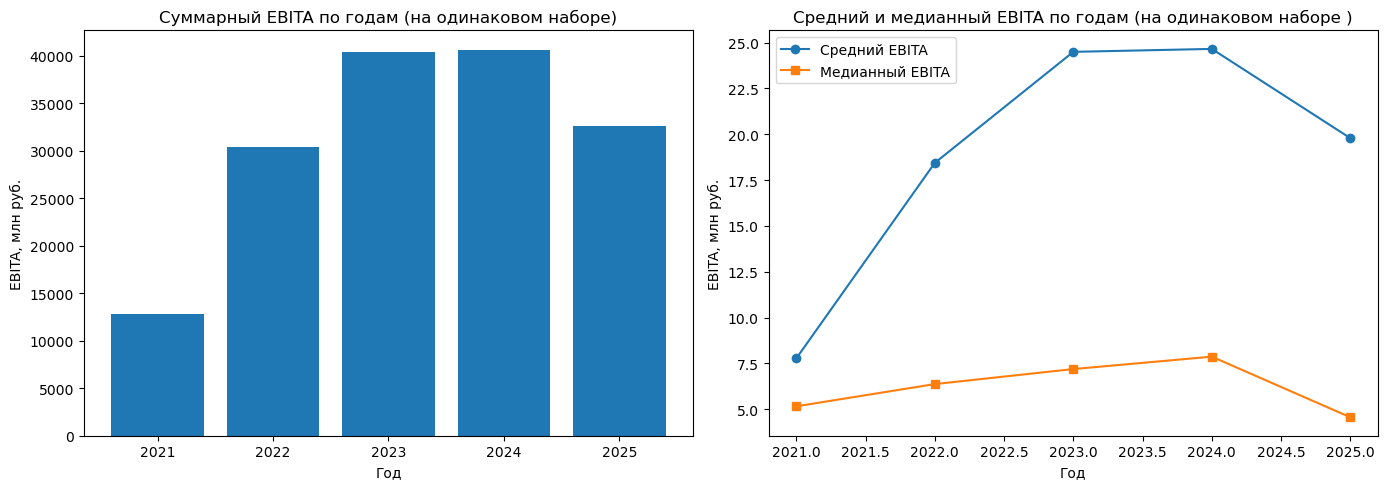

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(
    balanced_by_year.index.astype(str),
    balanced_by_year["sum"] / 1000)
axes[0].set_title("Суммарный EBITA по годам (на одинаковом наборе)")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("EBITA, млн руб.")
axes[1].plot(
    balanced_by_year.index,
    balanced_by_year["mean"] / 1000,
    marker="o",
    label="Средний EBITA")
axes[1].plot(
    balanced_by_year.index,
    balanced_by_year["median"] / 1000,
    marker="s",
    label="Медианный EBITA")
axes[1].set_title("Средний и медианный EBITA по годам (на одинаковом наборе )")
axes[1].set_xlabel("Год")
axes[1].set_ylabel("EBITA, млн руб.")
axes[1].legend()
plt.tight_layout()
plt.show()

In [85]:
zero_check = (
    balanced
    .groupby("Год")["EBITA_proxy"]
    .agg(
        Всего="count",
        Нулевых=lambda x: (x == 0).sum(),
        Отрицательных=lambda x: (x < 0).sum(),
        Положительных=lambda x: (x > 0).sum()))
zero_check["Доля_нулевых_%"] = (zero_check["Нулевых"] / zero_check["Всего"] * 100)
zero_check.round(2)

,Всего,Нулевых,Отрицательных,Положительных,Доля_нулевых_%
Год,,,,,
2021,1647,0,212,1435,0.00
2022,1647,1,210,1436,0.06
2023,1647,5,218,1424,0.30
2024,1647,6,249,1392,0.36
2025,1647,14,365,1268,0.85


#### Вывод 
На одинаковом наборе из 1647 компаний снижение EBITA в 2025 г. сохраняется. Доля нулевых значений незначительна, однако число компаний с отрицательным EBITA выросло с 249 до 365, что подтверждает ухудшение финансовых результатов части компаний отрасли.

### Распределение роста чистой прибыли

Выбран **N = 1 год** (сравнение с предыдущим годом).

Формула роста: `(прибыль_t − прибыль_(t−1)) / |прибыль_(t−1)| × 100`.

In [92]:
N = 1
growth_data = []
for year in [2022, 2023, 2024, 2025]:
    prev = finance[finance["Год"] == year - N][
        ["ИНН", "Чистая_прибыль_2400"].rename(columns={"Чистая_прибыль_2400": "profit_prev"})
    curr = finance[finance["Год"] == year][
        ["ИНН", "Чистая_прибыль_2400"]].rename(columns={"Чистая_прибыль_2400": "profit_curr"})
    temp = curr.merge(prev, on="ИНН")
    temp = temp[temp["profit_prev"] > 0].copy()
    temp["growth"] = (
        (temp["profit_curr"] - temp["profit_prev"])/ temp["profit_prev"]* 100)
    temp["year"] = year
    growth_data.append(temp)
growth = pd.concat(growth_data, ignore_index=True)

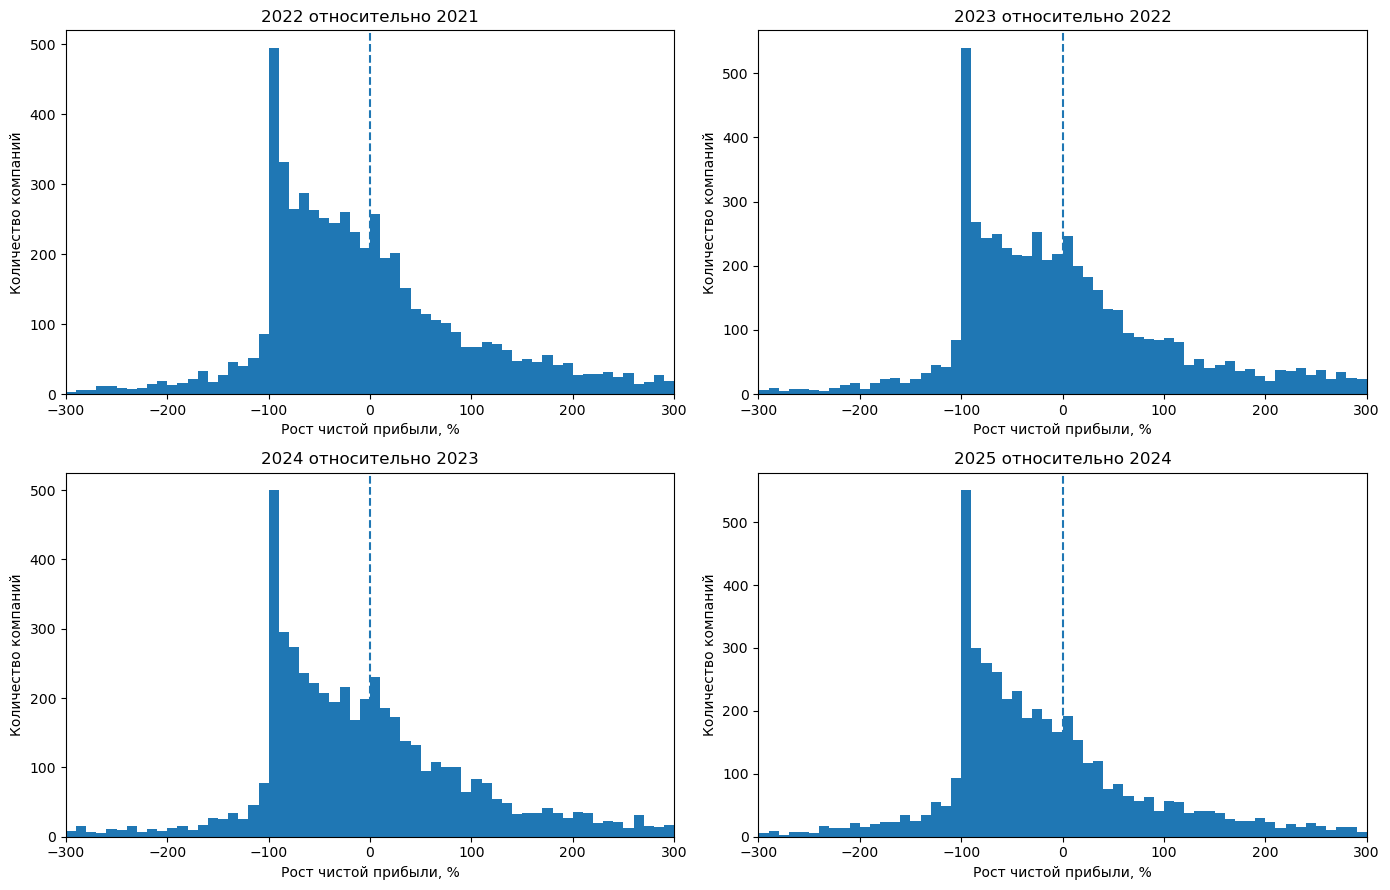

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, year in zip(axes.flatten(), [2022, 2023, 2024, 2025]):
    values = growth.loc[growth["year"] == year, "growth"]
    ax.hist(values,ins=range(-300, 310, 10))
    ax.axvline(0, linestyle="--")
    ax.set_title(f"{year} относительно {year - 1}")
    ax.set_xlabel("Рост чистой прибыли, %")
    ax.set_ylabel("Количество компаний")
    ax.set_xlim(-300, 300)
plt.tight_layout()
plt.show()

#### Вывод 

**Распределения** годового роста чистой прибыли для всех лет **имеют схожую форму**. При этом:

1. У значительной части компаний отрицательный рост прибыли.
2. Заметен выраженный пик около −100%, то есть много компаний ежегодно теряют почти всю прибыль относительно предыдущего года. 
3. Одновременно с этим присутствует тяжелый правый хвост, то есть немалая часть компаний демонстрирует высокий рост прибыли.
4. В 2025 году распределение остаётся смещённым в сторону отрицательных изменений, что согласуется с ранее выявленным ухудшением финансовых показателей отрасли.

### Карта 500 крупнейших компаний по выручке

За выручку компании берётся максимальное значение среди всех доступных лет. 

In [121]:
!pip install geopandas
import geopandas as gpd

     ---------------------------------------- 0.0/40.8 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.8 kB ? eta -:--:--
     ---------------------------- --------- 30.7/40.8 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 40.8/40.8 kB 244.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/343.3 kB ? eta -:--:--
   ---- ---------------------------------- 41.0/343.3 kB 991.0 kB/s eta 0:00:01
   ---- ---------------------------------- 41.0/343.3 kB 991.0 kB/s eta 0:00:01
   -------- ------------------------------ 71.7/343.3 kB 563.7 kB/s eta 0:00:01
   ----------------- -------------------- 153.6/343.3 kB 919.0 kB/s eta 0:00:01
   ------------------- ------------------ 174.1/343.3 kB 952.6 kB/s eta 0:00:01
   -------------------------- ----------- 235.5/343.3 kB 901.1 kB/s eta 0:00:01
   ---------------------------------------  337.9/343.3 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 343.3/343.3 kB 1.1 M

In [123]:
top500 = (finance.groupby("ИНН", as_index=False)["Выручка_2110"].max()nlargest(500, "Выручка_2110"))
top500.head()

,ИНН,Выручка_2110
8186,8601049319,77138000.0
3838,5401304044,18261572.0
6166,7702681515,14902058.0
6659,7718894438,14352296.0
6360,7708409097,12516249.0


In [131]:
top500["ИНН"] = top500["ИНН"].astype(str)
df["ИНН"] = df["ИНН"].astype(str)
top500 = top500.merge(df[["ИНН", "Регион"]],on="ИНН", how="left")
top500.head()

,ИНН,Выручка_2110,Регион_x,Регион_y,Регион
0,8601049319,77138000.0,86 - Ханты-Мансийский автономный округ - Югра,86 - Ханты-Мансийский автономный округ - Югра,86 - Ханты-Мансийский автономный округ - Югра
1,5401304044,18261572.0,54 - Новосибирская область,54 - Новосибирская область,54 - Новосибирская область
2,7702681515,14902058.0,77 - г.Москва,77 - г.Москва,77 - г.Москва
3,7718894438,14352296.0,77 - г.Москва,77 - г.Москва,77 - г.Москва
4,7708409097,12516249.0,77 - г.Москва,77 - г.Москва,77 - г.Москва


In [137]:
regions = gpd.read_file( "https://raw.githubusercontent.com/imsha/russia_geojson_regions_2021/main/ru.json")
print(regions.shape)
regions

(84, 3)


,id,name,geometry
0,3,Республика Бурятия,"POLYGON ((99.23057 52.96319, 99.24053 52.98642..."
1,9,Карачаево-Черкесская Республика,"POLYGON ((41.73682 44.47313, 41.79264 44.47052..."
2,65,Сахалинская область,"MULTIPOLYGON (((145.98748 43.36928, 146.01625 ..."
3,36,Воронежская область,"POLYGON ((38.29261 51.96594, 38.32064 51.98361..."
4,70,Томская область,"POLYGON ((75.10824 58.57624, 75.1993 58.61868,..."
...,...,...,...
79,35,Вологодская область,"POLYGON ((34.72236 59.08485, 34.75214 59.09343..."
80,6,Республика Ингушетия,"POLYGON ((44.84761 43.56497, 44.86736 43.55849..."
81,74,Челябинская область,"POLYGON ((59.04205 56.16836, 59.03005 56.17331..."
82,2,Республика Башкортостан,"POLYGON ((53.69734 55.92508, 53.70572 55.93304..."


In [143]:
top500["region_id"] = (top500["Регион"].str.extract(r"^(\d+)")[0].astype("Int64"))
top500[["Регион", "region_id"]]

,Регион,region_id
0,86 - Ханты-Мансийский автономный округ - Югра,86
1,54 - Новосибирская область,54
2,77 - г.Москва,77
3,77 - г.Москва,77
4,77 - г.Москва,77
...,...,...
495,20 - Чеченская Республика,20
496,50 - Московская область,50
497,77 - г.Москва,77
498,35 - Вологодская область,35


In [145]:
region_points = regions.to_crs(epsg=3857).copy()
region_points["geometry"] = (region_points.geometry.representative_point())
region_points = region_points.to_crs(epsg=4326)

In [147]:
top500_geo = top500.merge(region_points[["id", "geometry"]],left_on="region_id",right_on="id",how="left")

top500_geo = gpd.GeoDataFrame(top500_geo,
    geometry="geometry",
    crs="EPSG:4326")

In [151]:
top500_geo = top500_geo.sort_values("Выручка_2110")

In [155]:
region_top500 = (
    top500_geo
    .groupby("region_id")
    .agg(
        Количество_компаний=("ИНН", "count"),
        Суммарная_выручка=("Выручка_2110", "sum"),
        geometry=("geometry", "first")
    )
    .reset_index()
)

region_top500 = gpd.GeoDataFrame(
    region_top500,
    geometry="geometry",
    crs="EPSG:4326"
)

region_top500.sort_values(
    "Количество_компаний",
    ascending=False
).head(10)

,region_id,Количество_компаний,Суммарная_выручка,geometry
59,77,149,534555755.0,POINT (37.35505 55.55382)
60,78,46,153318263.0,POINT (30.34875 59.94551)
37,50,36,118856536.0,POINT (38.92714 55.633)
7,16,32,102070547.0,POINT (50.78203 55.34537)
49,66,22,67855243.0,POINT (62.2296 59.11446)
14,23,20,63779834.0,POINT (38.06629 45.15769)
63,91,9,28901906.0,None
56,74,8,19269449.0,POINT (61.56253 54.23435)
0,2,8,18071210.0,POINT (56.3686 54.12872)
43,59,7,16419454.0,POINT (56.44908 58.98259)


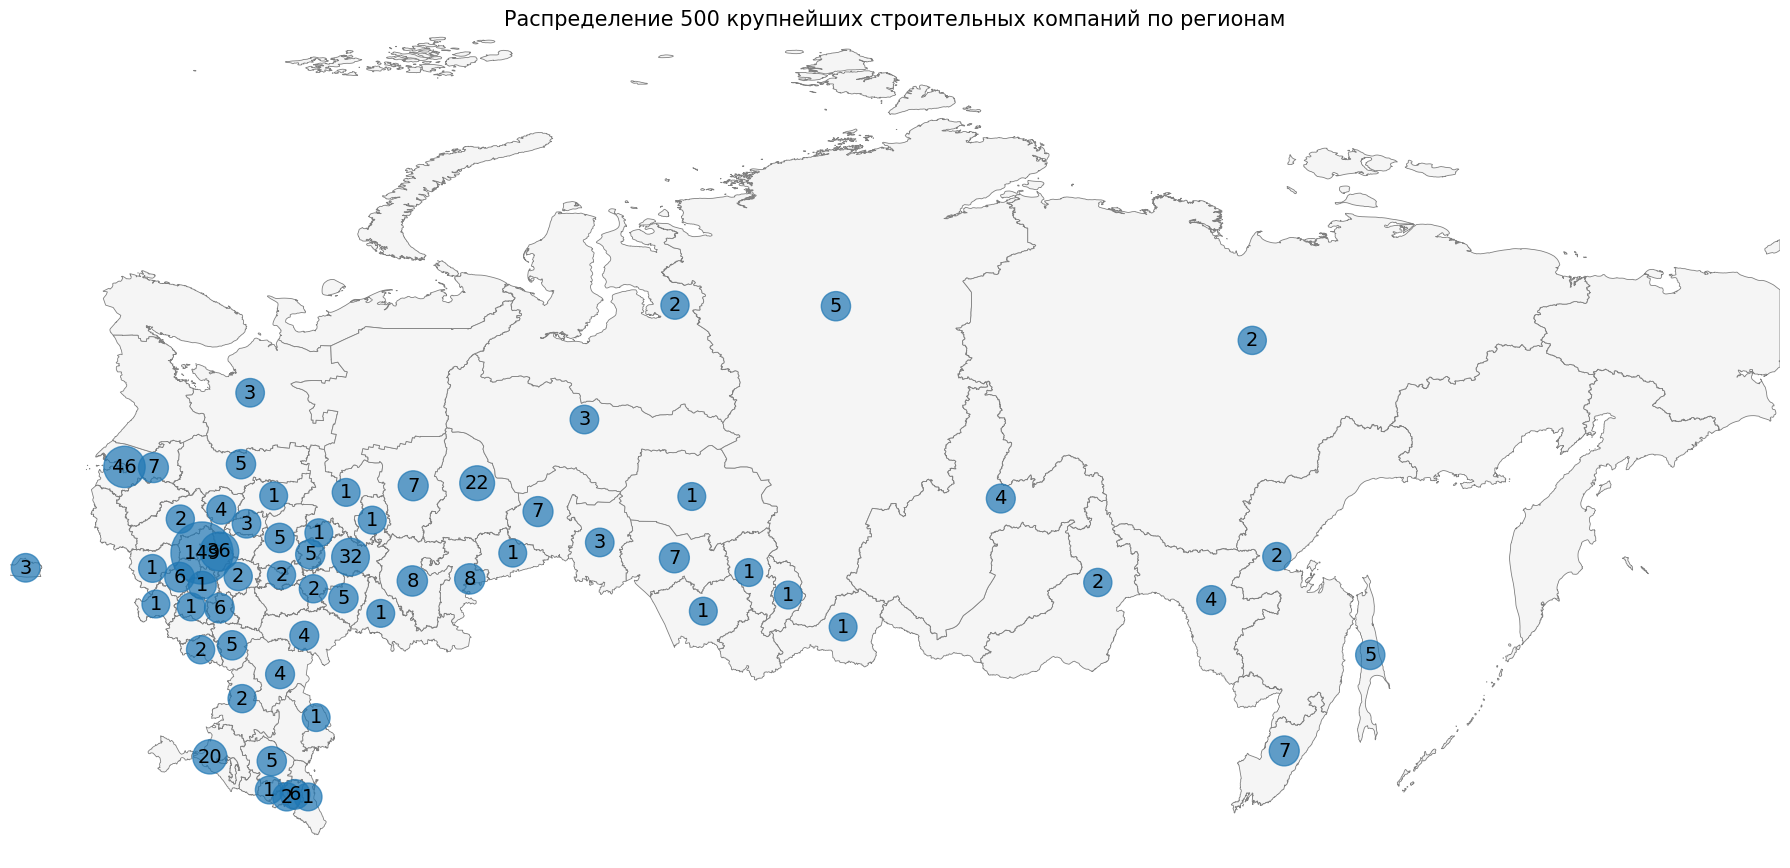

In [209]:
min_size = 400
max_size = 2000
min_count = region_top500["Количество_компаний"].min()
max_count = region_top500["Количество_компаний"].max()

region_top500["marker_size"] = (
    min_size
    + (region_top500["Количество_компаний"] - min_count)
    * (max_size - min_size)
    / (max_count - min_count))
fig, ax = plt.subplots(figsize=(18, 10))

regions.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="gray",
    linewidth=0.6
)

region_top500.plot(
    ax=ax,
    markersize=region_top500["marker_size"],
    alpha=0.7
)

for _, row in region_top500.iterrows():
    if row.geometry is not None:
        ax.text(
            row.geometry.x,
            row.geometry.y,
            str(int(row["Количество_компаний"])),
            fontsize=14,
            ha="center",
            va="center")

ax.set_xlim(20, 180)
ax.set_ylim(40, 82)

ax.set_title(
    "Распределение 500 крупнейших строительных компаний по регионам",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()